In [1]:
#pip install kaggle
#https://www.kaggle.com/datasets/rhythmghai/netflix-user-watching-behavior-dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import KNNImputer
import processing as pr

data = pd.read_csv("netflix.csv")

data.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No


In [2]:

# удаление незначимых признаков
df=data.copy()
df=df.drop(['user_id', 'primary_device','country','payment_method','primary_device','devices_used'], axis=1) #'gender'
df.head()

,age,gender,account_age_months,subscription_type,monthly_fee,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,56,Male,17,Standard,15.99,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,46,Female,20,Standard,12.99,Documentary,76,15,4,71,4.6,7,78,14,No
2,32,Other,25,Basic,15.99,Comedy,215,6,13,33,2.0,27,29,41,No
3,60,Male,37,Standard,12.99,Action,280,4,9,58,1.2,9,23,22,No
4,25,Male,23,Premium,12.99,Horror,261,15,9,64,1.3,49,56,54,No


In [3]:
#оцифровка значений df
df=pr.convert_to_numeric(df)
df.head()

gender: категориальная -> 3 категорий
subscription_type: порядковая -> {'Basic': 1, 'Standard': 2, 'Premium': 2}
favorite_genre: категориальная -> 8 категорий
churned: бинарная -> {'No': 0, 'Yes': 1}


,age,gender,account_age_months,subscription_type,monthly_fee,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,56,0,17,2,15.99,0,220,17,3,60,1.7,5,66,16,0
1,46,1,20,2,12.99,1,76,15,4,71,4.6,7,78,14,0
2,32,2,25,1,15.99,2,215,6,13,33,2.0,27,29,41,0
3,60,0,37,2,12.99,3,280,4,9,58,1.2,9,23,22,0
4,25,0,23,2,12.99,4,261,15,9,64,1.3,49,56,54,0


In [4]:
#посчитаем пропущенные значения и в каких столбцах
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    print("Столбцы с пропущенными значениями и их количество:")
    print(missing_values)
else:
    print("Пропущенных значений нет ни в одном столбце.")

print(f'Количество пропущенных значений в датасете: {df.isnull().sum().sum()}')

Пропущенных значений нет ни в одном столбце.
Количество пропущенных значений в датасете: 0


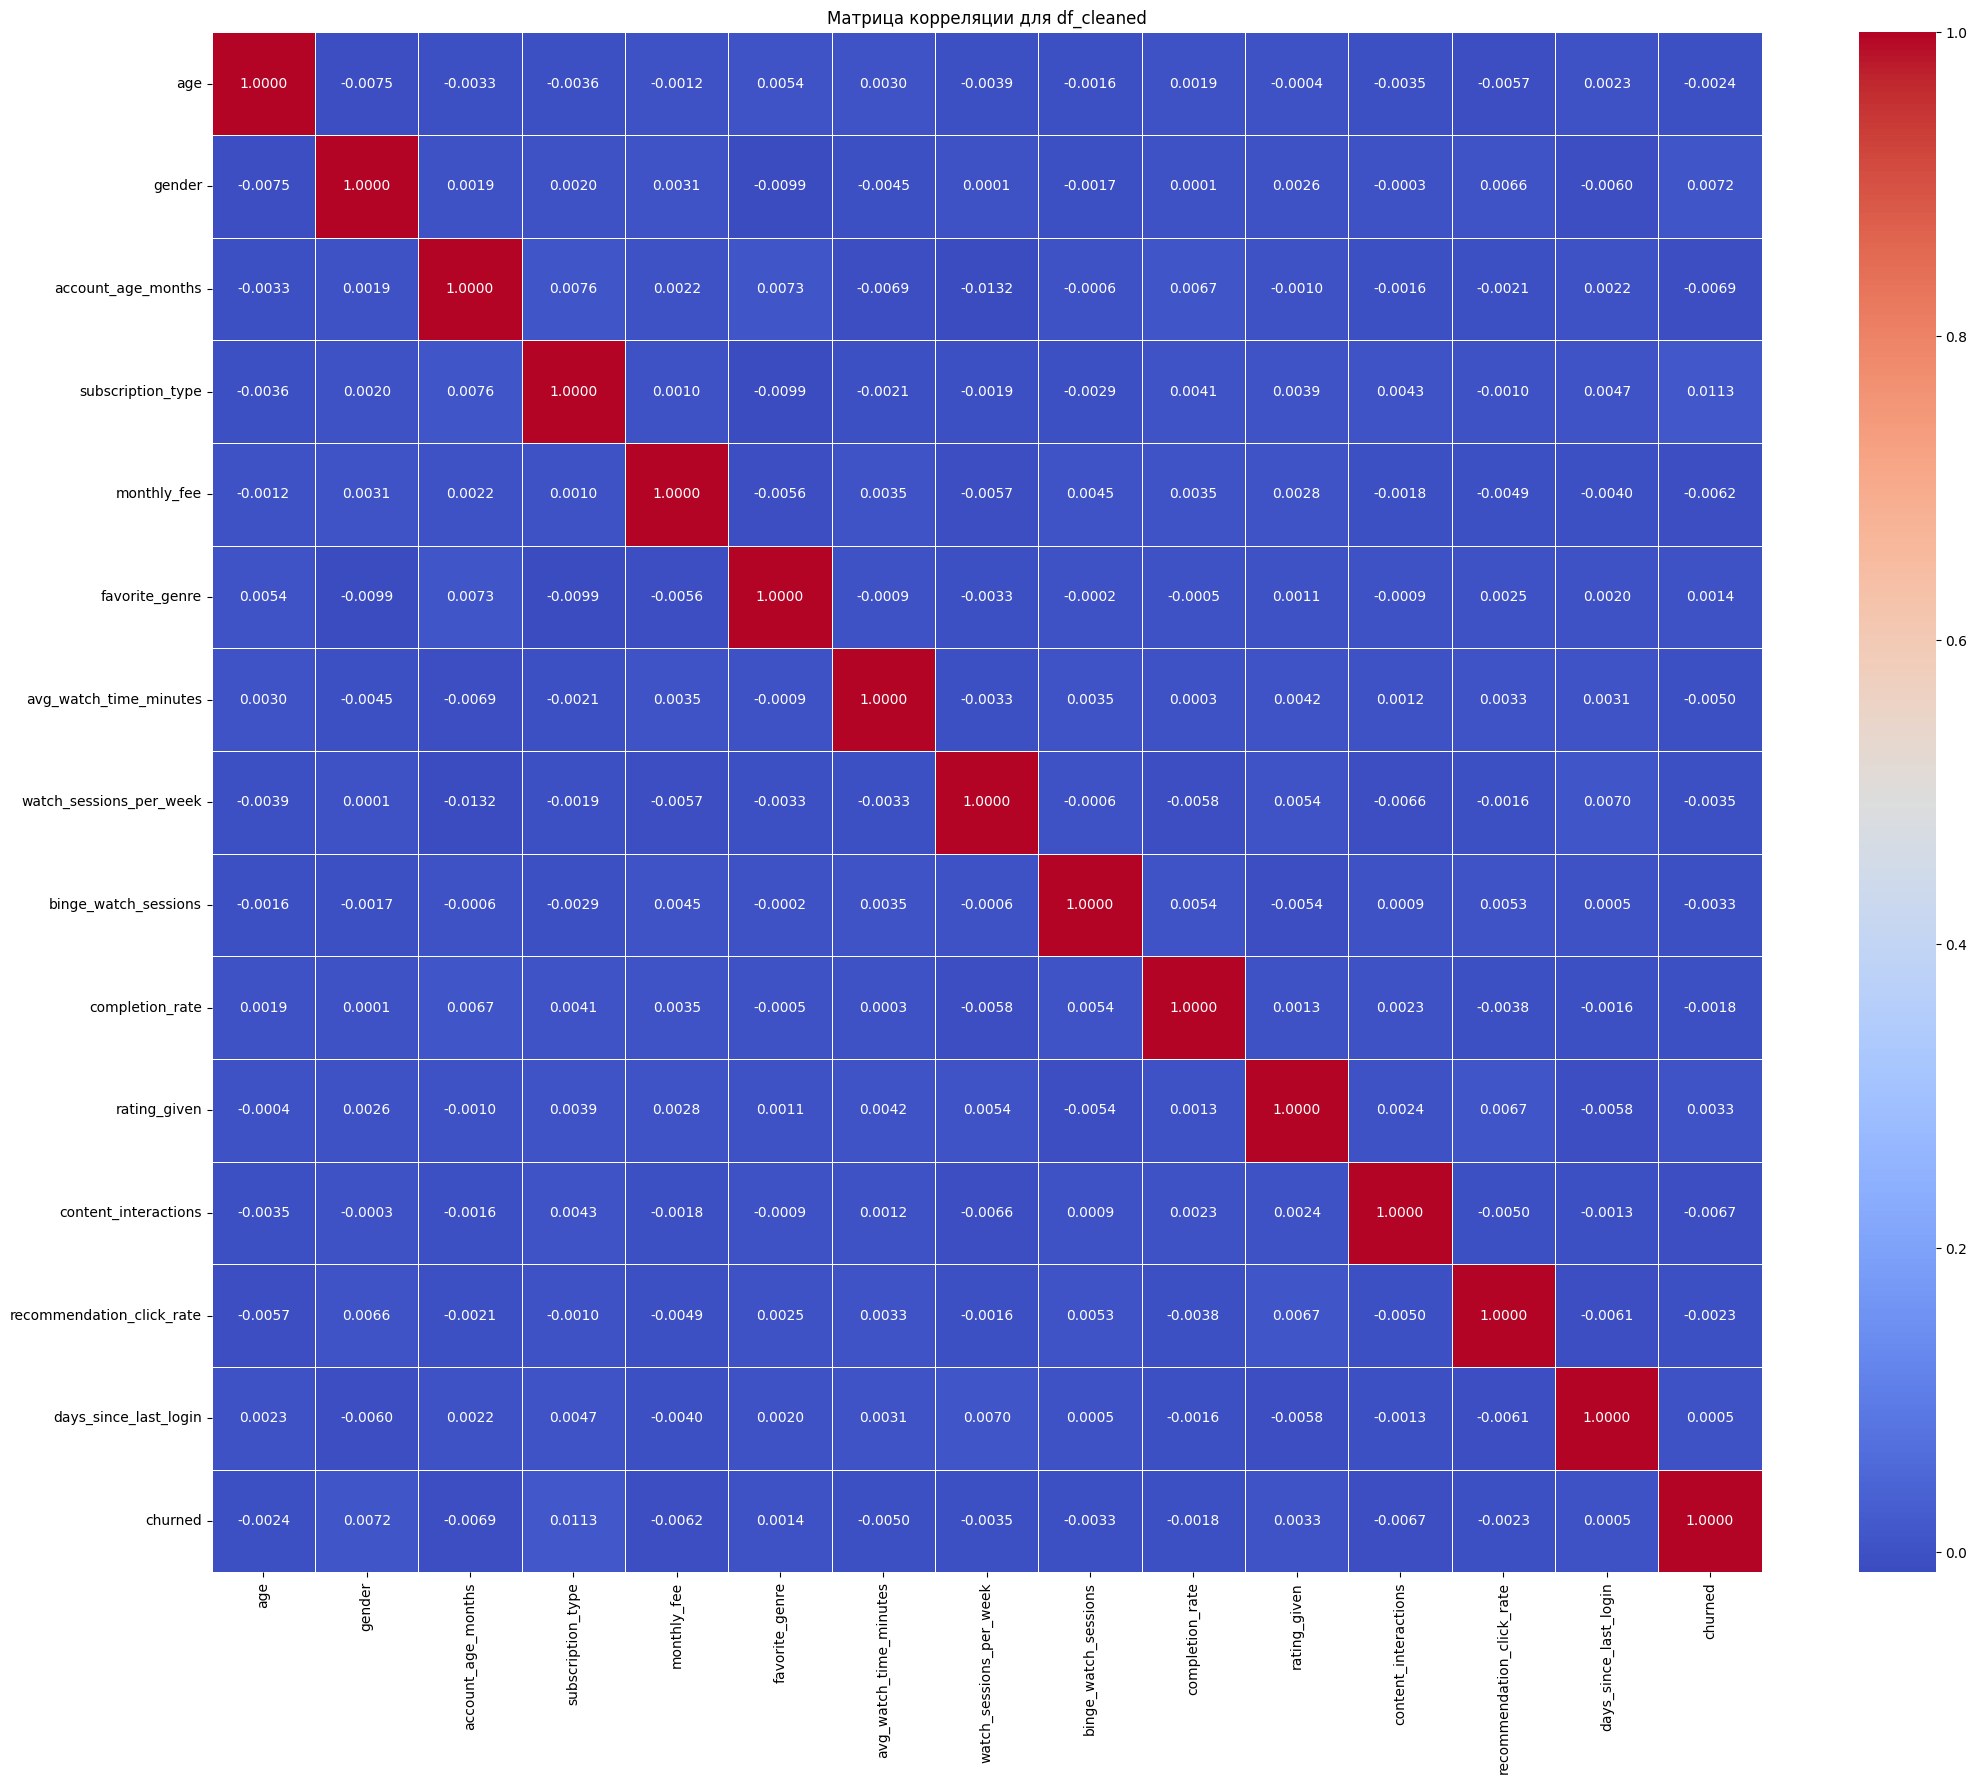

In [5]:
# построение матрицы корреляции
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


correlation_matrix = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(25, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.4f', linewidths=.5)
plt.title('Матрица корреляции для df_cleaned')
plt.show()

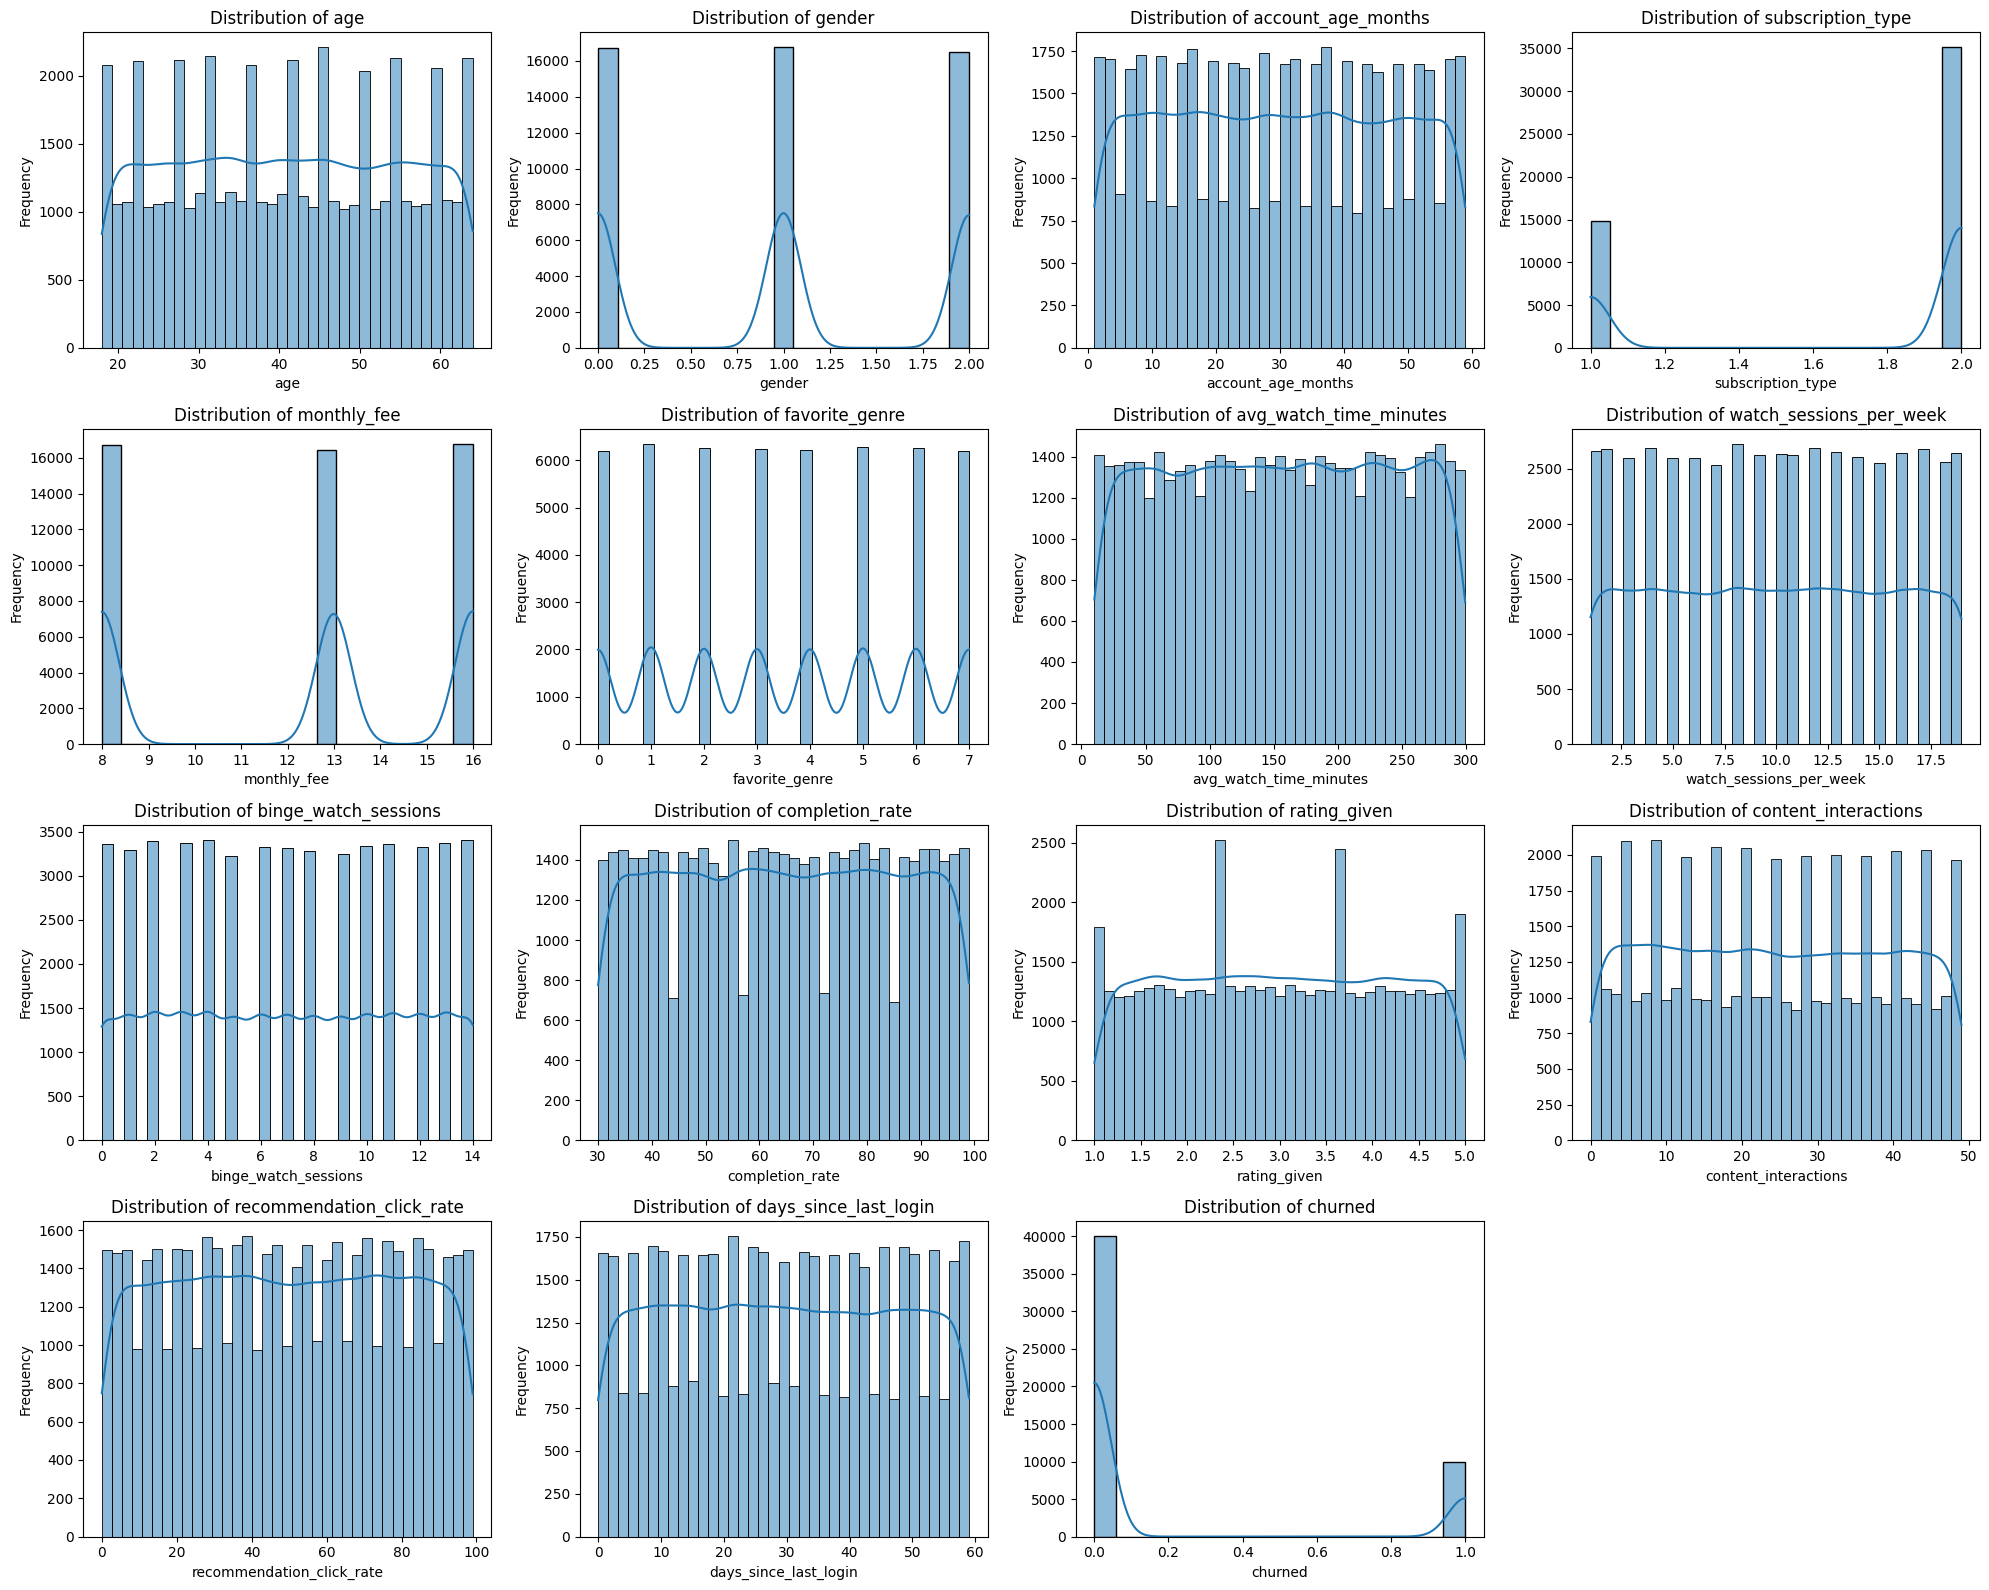

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the number of columns in the DataFrame
num_cols = df.shape[1]

num_rows = (num_cols + 3) // 4
num_cols_per_row = min(num_cols, 4)

plt.figure(figsize=(num_cols_per_row * 5, num_rows * 4))

for i, col in enumerate(df.columns):
    plt.subplot(num_rows, num_cols_per_row, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

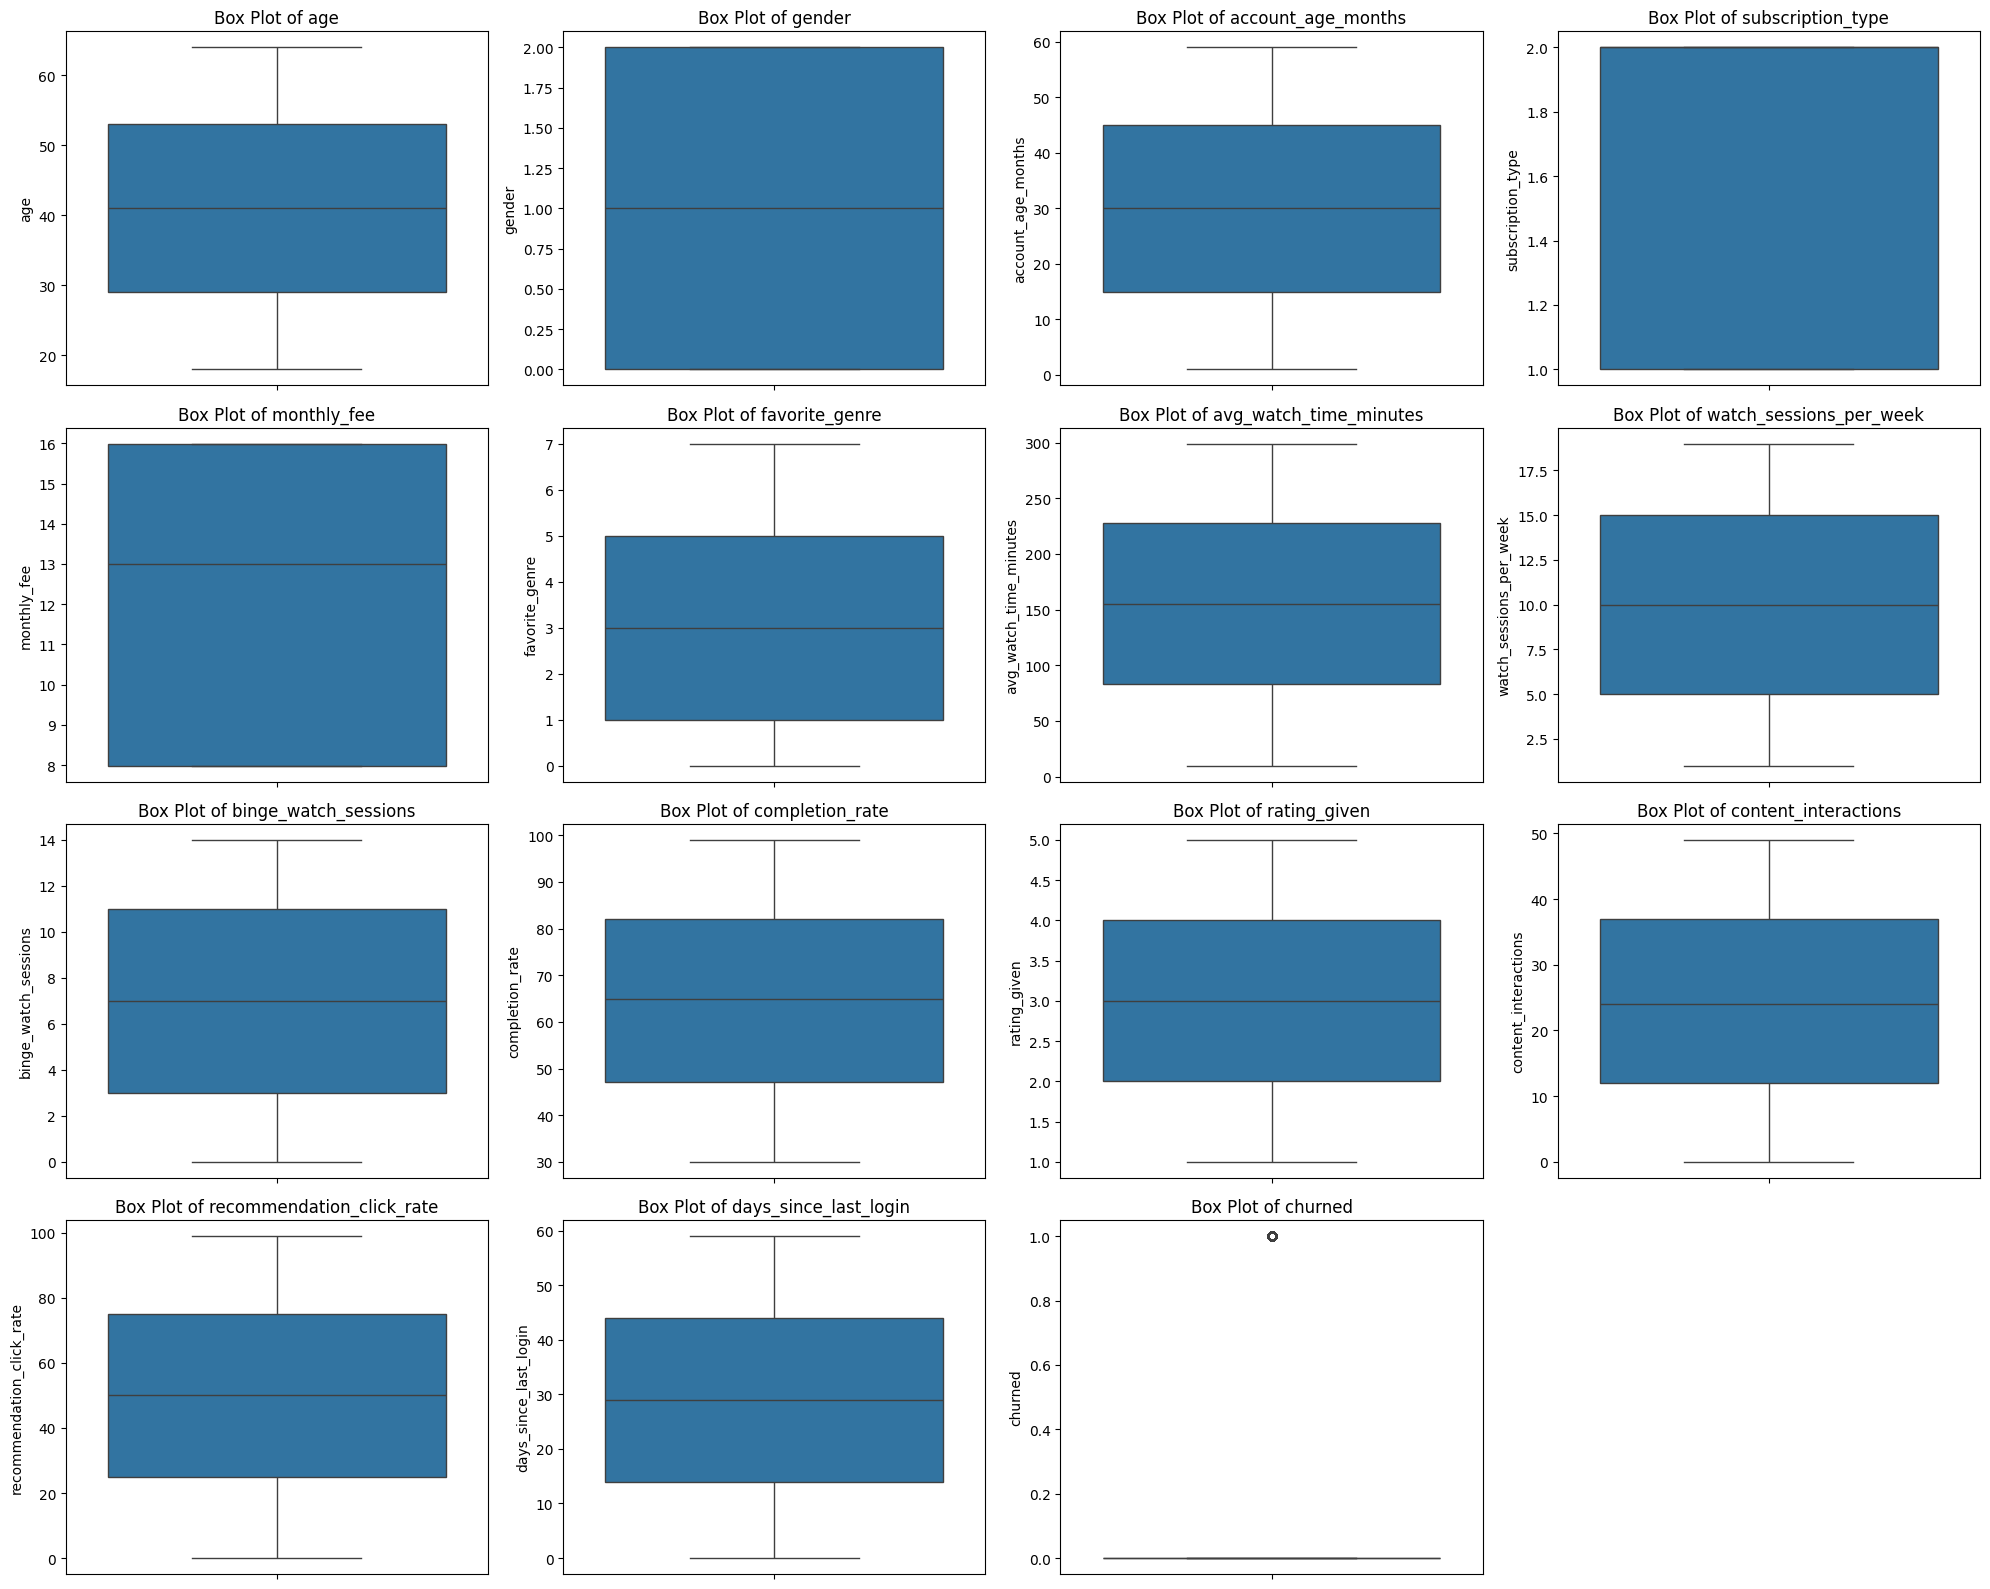

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numerical_cols = df.select_dtypes(include=np.number).columns

num_cols = len(numerical_cols)
num_rows = (num_cols + 3) // 4
num_cols_per_row = min(num_cols, 4)

plt.figure(figsize=(num_cols_per_row * 5, num_rows * 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, num_cols_per_row, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [8]:
df = df.drop('churned', axis=1)
print("Столбец 'churned' успешно удален.")
df.head()

Столбец 'churned' успешно удален.


,age,gender,account_age_months,subscription_type,monthly_fee,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login
0,56,0,17,2,15.99,0,220,17,3,60,1.7,5,66,16
1,46,1,20,2,12.99,1,76,15,4,71,4.6,7,78,14
2,32,2,25,1,15.99,2,215,6,13,33,2.0,27,29,41
3,60,0,37,2,12.99,3,280,4,9,58,1.2,9,23,22
4,25,0,23,2,12.99,4,261,15,9,64,1.3,49,56,54


Anomaly detection completed. Added 'anomaly' column to DataFrame. (-1 = anomaly, 1 = normal)
Anomaly counts:
anomaly
 1    4950
-1      50
Name: count, dtype: int64


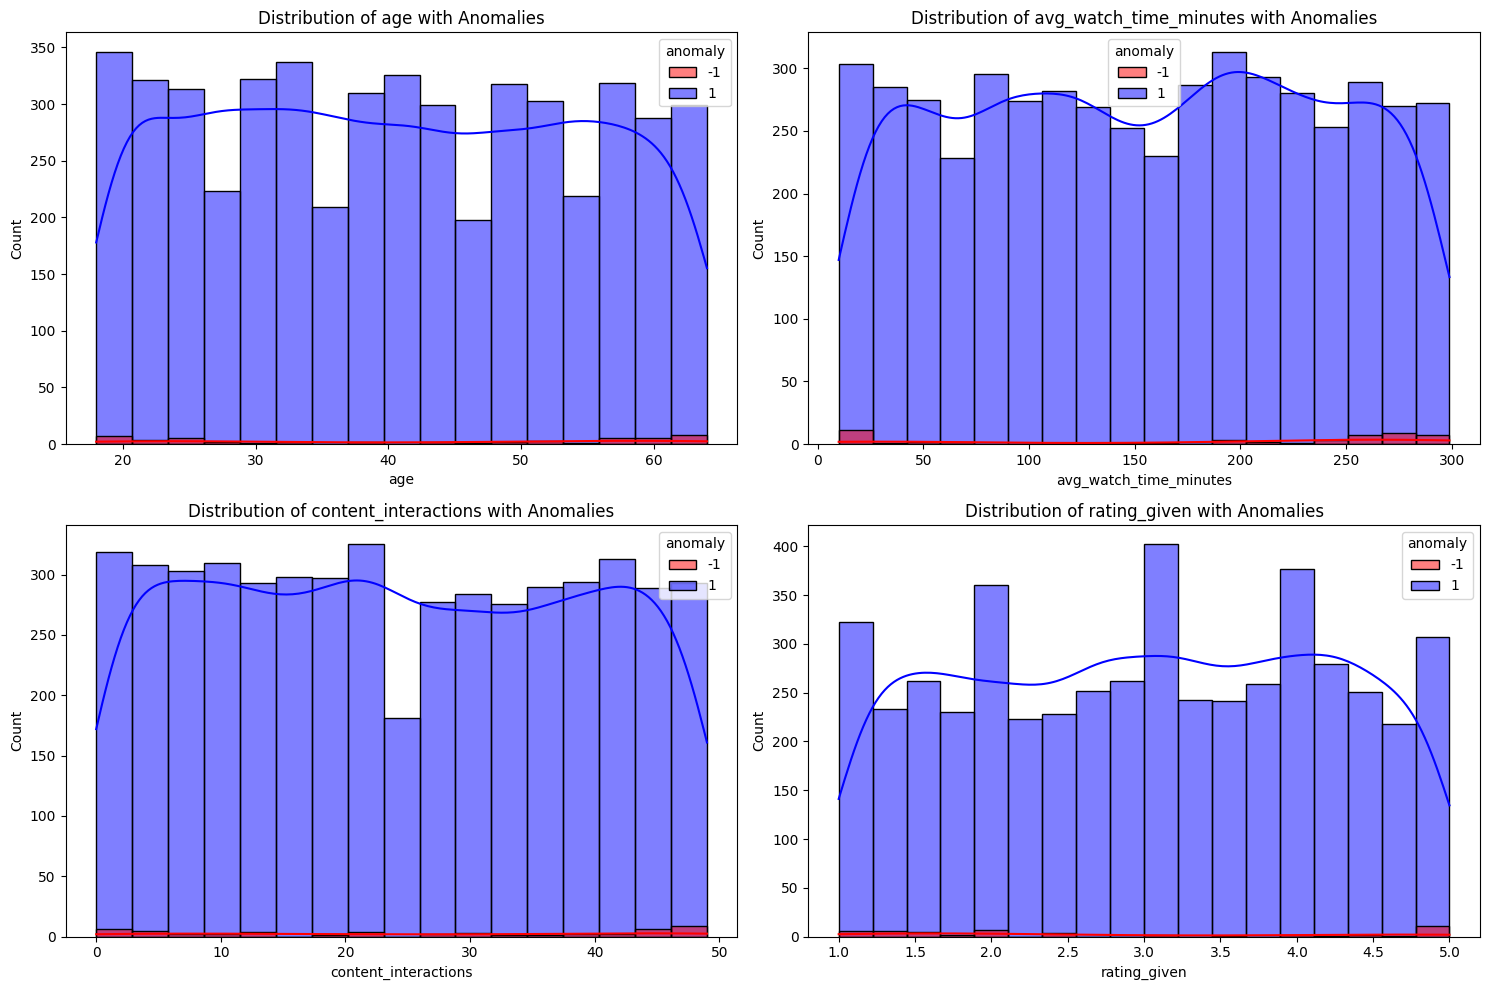

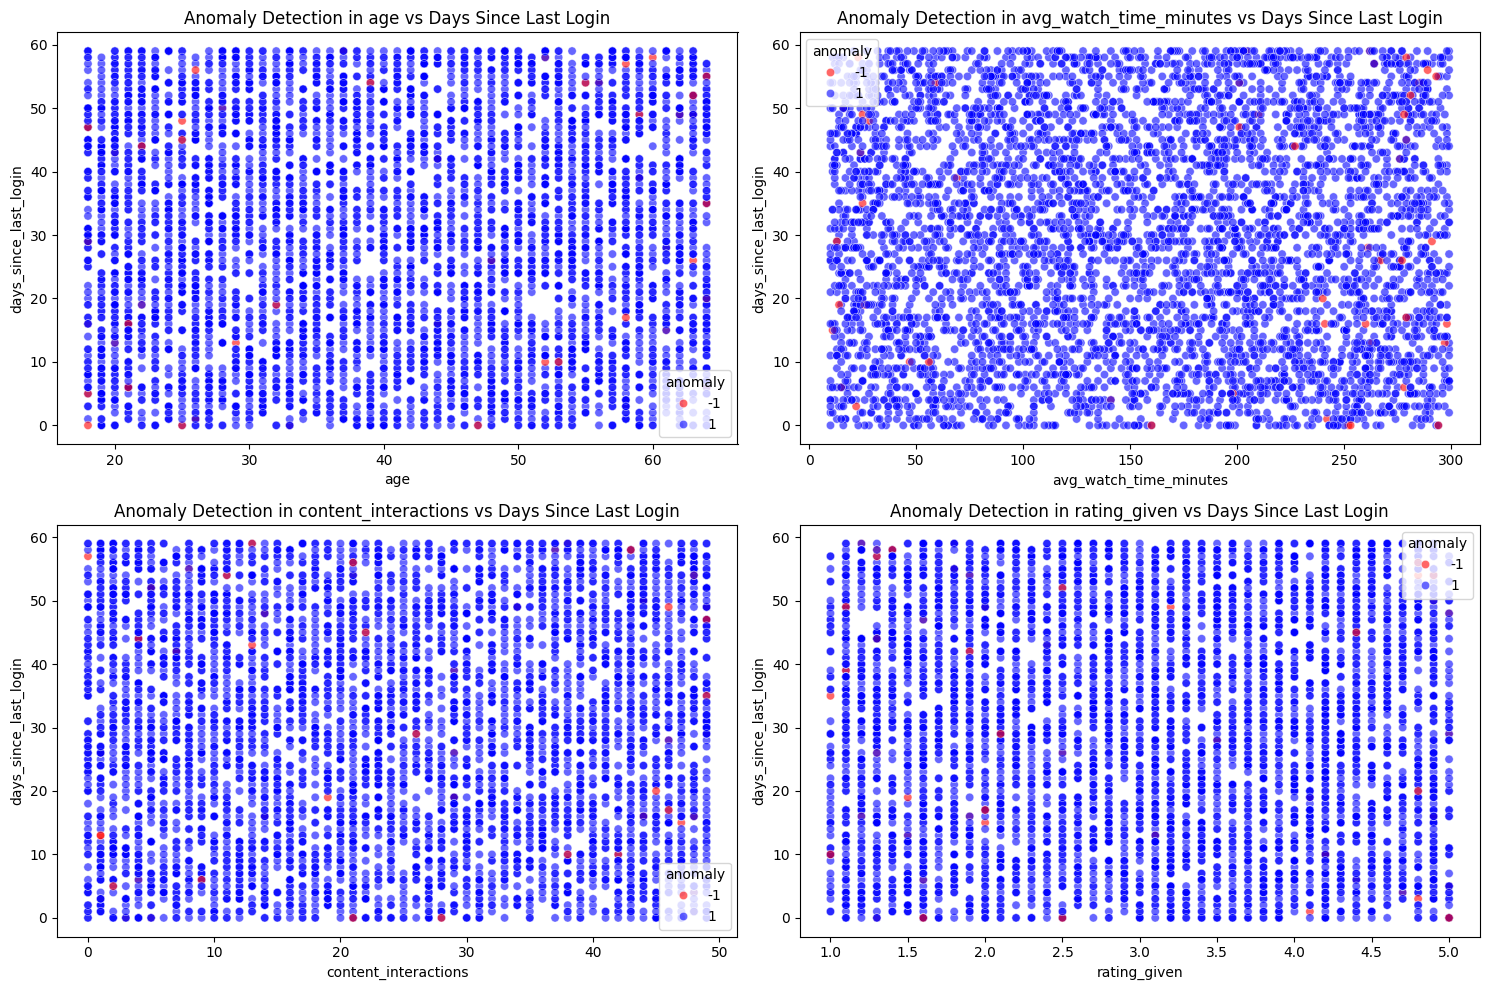

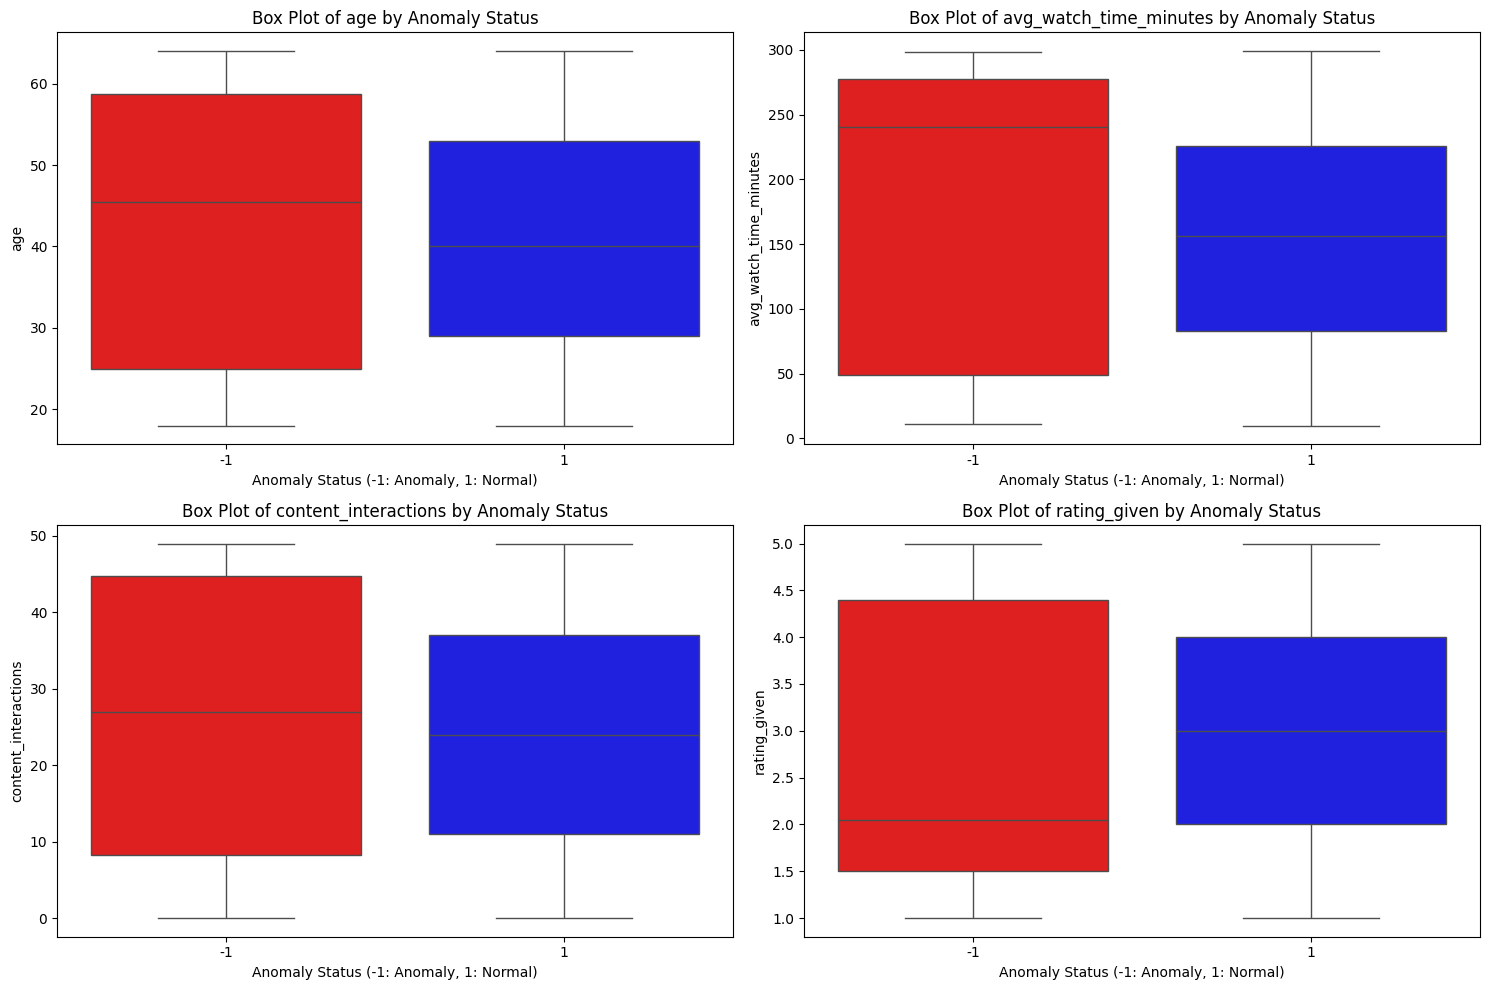

In [17]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Определение аномалий
numerical_cols_for_anomaly = df.select_dtypes(include=np.number).columns.tolist()
if 'segment' in numerical_cols_for_anomaly:
    numerical_cols_for_anomaly.remove('segment')

df_anomaly = df[numerical_cols_for_anomaly].copy()

# Scale the data for anomaly detection
scaler_anomaly = StandardScaler()
scaled_df_anomaly = scaler_anomaly.fit_transform(df_anomaly)
scaled_df_anomaly = pd.DataFrame(scaled_df_anomaly, columns=numerical_cols_for_anomaly)

# Apply Isolation Forest
# contamination is the proportion of outliers in the data set. Often set between 0.01 and 0.05
isolation_forest = IsolationForest(random_state=42, contamination=0.01, n_estimators=100, n_jobs=-1)
# Predict -1 for outliers and 1 for inliers
df['anomaly'] = isolation_forest.fit_predict(scaled_df_anomaly)

print("Anomaly detection completed. Added 'anomaly' column to DataFrame. (-1 = anomaly, 1 = normal)")
print("Anomaly counts:")
print(df['anomaly'].value_counts())

# Visualize anomalies for a few key features
# Choose a few representative numerical columns for visualization
plot_cols = ['age', 'avg_watch_time_minutes', 'content_interactions', 'rating_given']

plt.figure(figsize=(15, 10))
for i, col in enumerate(plot_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data=df, x=col, hue='anomaly', kde=True, palette={1: 'blue', -1: 'red'})
    plt.title(f'Distribution of {col} with Anomalies')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, col in enumerate(plot_cols):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(data=df, x=col, y='days_since_last_login', hue='anomaly', palette={1: 'blue', -1: 'red'}, alpha=0.6)
    plt.title(f'Anomaly Detection in {col} vs Days Since Last Login')
plt.tight_layout()
plt.show()

# New visualization: Box plots of key features by anomaly status
plt.figure(figsize=(15, 10))
for i, col in enumerate(plot_cols):
    plt.subplot(2, 2, i + 1)
    # Convert 'anomaly' column to string type to match palette keys
    sns.boxplot(data=df, x='anomaly', y=col, palette={'-1': 'red', '1': 'blue'})
    plt.title(f'Box Plot of {col} by Anomaly Status')
    plt.xlabel('Anomaly Status (-1: Anomaly, 1: Normal)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [10]:
print("Записи, помеченные как аномалии:")
display(df[df['anomaly'] == -1])

Записи, помеченные как аномалии:


,age,gender,account_age_months,subscription_type,monthly_fee,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,anomaly
84,64,1,1,1,7.99,3,168,2,14,89,1.1,13,15,1,-1
93,18,2,14,2,7.99,1,13,17,1,60,1.3,11,65,0,-1
98,18,0,5,1,7.99,0,254,3,11,32,4.6,6,46,41,-1
135,22,0,10,1,12.99,7,12,6,10,30,1.1,11,11,19,-1
205,19,2,9,1,7.99,0,246,19,0,98,1.3,27,84,9,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49746,62,2,34,1,15.99,2,292,18,9,48,1.3,5,70,56,-1
49815,42,2,15,1,7.99,0,264,4,9,98,1.4,3,78,52,-1
49878,63,0,3,2,7.99,6,290,5,0,83,5.0,2,26,8,-1
49933,44,0,52,2,7.99,6,115,5,1,31,1.7,0,95,1,-1


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from imblearn.over_sampling import SMOTE # Import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Ensure 'processing' module is imported for pr.convert_to_numeric
import processing as pr

# Load the initial dataset (added here to ensure 'data' is defined)
data = pd.read_csv("netflix.csv")

# --- Data Preparation for Classification ---
# Create a new DataFrame for modeling to ensure 'churned' is available as the target
df_model_prep = data.copy()

# Apply feature removal as done in cell ptBxB3G098CY
df_model_prep = df_model_prep.drop(['user_id', 'primary_device', 'country', 'payment_method', 'devices_used'], axis=1)

# Apply numerical conversion as done in cell q4mTeL-ODsVY
df_model_prep = pr.convert_to_numeric(df_model_prep)

# Separate features (X) and target (y)
X = df_model_prep.drop('churned', axis=1)
y = df_model_prep['churned']

# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Identify numerical columns for preprocessing
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

# Create a preprocessor for numerical features (scaling)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough' # Keep other columns if any, though none are expected here
)

# Apply SMOTE to the training data *after* splitting to prevent data leakage
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape}, {y_train.shape}")
print(f"Resampled training set shape: {X_train_resampled.shape}, {y_train_resampled.shape}")
print(f"Class distribution in original training set: {pd.Series(y_train).value_counts()}")
print(f"Class distribution in resampled training set: {pd.Series(y_train_resampled).value_counts()}")


# Создадим список для хранения результатов КЛАССИФИКАЦИИ
classification_results = []

# Функция для оценки и печати результатов
def evaluate_model(model, model_name, X_train_data, X_test_data, y_train_data, y_test_data, preprocessor):
    # Создаем пайплайн с предобработкой и моделью
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', model)])

    # Обучаем
    pipeline.fit(X_train_data, y_train_data)

    # Предсказываем
    y_pred = pipeline.predict(X_test_data)

    # Оцениваем
    accuracy = accuracy_score(y_test_data, y_pred)
    # Provide string target names based on the conversion ('No': 0, 'Yes': 1)
    target_names_for_report = ['No', 'Yes']
    report = classification_report(y_test_data, y_pred, target_names=target_names_for_report, output_dict=True)

    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test_data, y_pred, target_names=target_names_for_report))

    classification_results.append({'Model': model_name, 'Accuracy': accuracy})

    return pipeline

# 1. Логистическая регрессия
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_pipeline = evaluate_model(lr_model, "Logistic Regression", X_train_resampled, X_test, y_train_resampled, y_test, preprocessor)

# 2. Случайный лес
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_pipeline = evaluate_model(rf_model, "Random Forest", X_train_resampled, X_test, y_train_resampled, y_test, preprocessor)

# 3. XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='mlogloss')
xgb_pipeline = evaluate_model(xgb_model, "XGBoost", X_train_resampled, X_test, y_train_resampled, y_test, preprocessor)

# 4. Метод опорных векторов (SVM) - может быть медленным, поэтому используем малую подвыборку для демонстрации
# Чтобы ускорить, возьмем часть данных для SVM
print("\n--- SVM (обучение на 20% данных для скорости) ---")
X_train_svm, _, y_train_svm, _ = train_test_split(X_train_resampled, y_train_resampled, train_size=0.2, random_state=42, stratify=y_train_resampled)
svm_model = SVC(kernel='rbf', random_state=42)
svm_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', svm_model)])
svm_pipeline.fit(X_train_svm, y_train_svm)
y_pred_svm = svm_pipeline.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy: {accuracy_svm:.4f}")
classification_results.append({'Model': 'SVM (RBF)', 'Accuracy': accuracy_svm})

# 5. Нейронная сеть (Keras)
# Для нейросети нам нужно преобразовать данные отдельно и целевую переменную в one-hot
print("\n--- Neural Network (Keras) ---")
# Преобразуем X_train и X_test через препроцессор
X_train_processed = preprocessor.fit_transform(X_train_resampled)
X_test_processed = preprocessor.transform(X_test)
# One-hot encoding для целевой переменной
y_train_cat = to_categorical(y_train_resampled, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# Строим модель
model_nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_nn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Ранняя остановка, чтобы не переобучаться
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Обучение
history = model_nn.fit(
    X_train_processed, y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=0
)

# Оценка
loss, accuracy_nn = model_nn.evaluate(X_test_processed, y_test_cat, verbose=0)
print(f"Accuracy: {accuracy_nn:.4f}")
classification_results.append({'Model': 'Neural Network', 'Accuracy': accuracy_nn})

age: уже числовая
gender: категориальная -> 3 категорий
   age  gender  account_age_months subscription_type  monthly_fee  \
0   56       1                  17          Standard        15.99   
1   46       0                  20          Standard        12.99   
2   32       2                  25             Basic        15.99   
3   60       1                  37          Standard        12.99   
4   25       1                  23           Premium        12.99   

  favorite_genre  avg_watch_time_minutes  watch_sessions_per_week  \
0         Sci-Fi                     220                       17   
1    Documentary                      76                       15   
2         Comedy                     215                        6   
3         Action                     280                        4   
4         Horror                     261                       15   

   binge_watch_sessions  completion_rate  rating_given  content_interactions  \
0                     3           

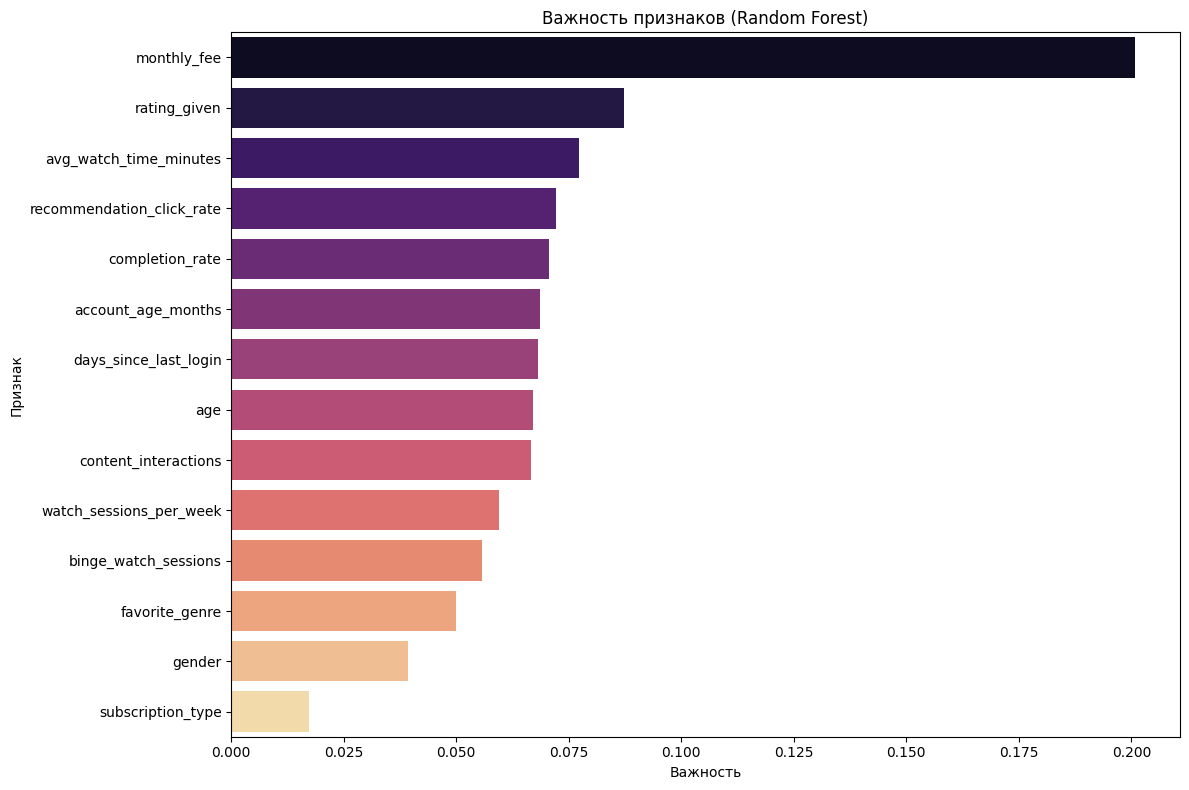

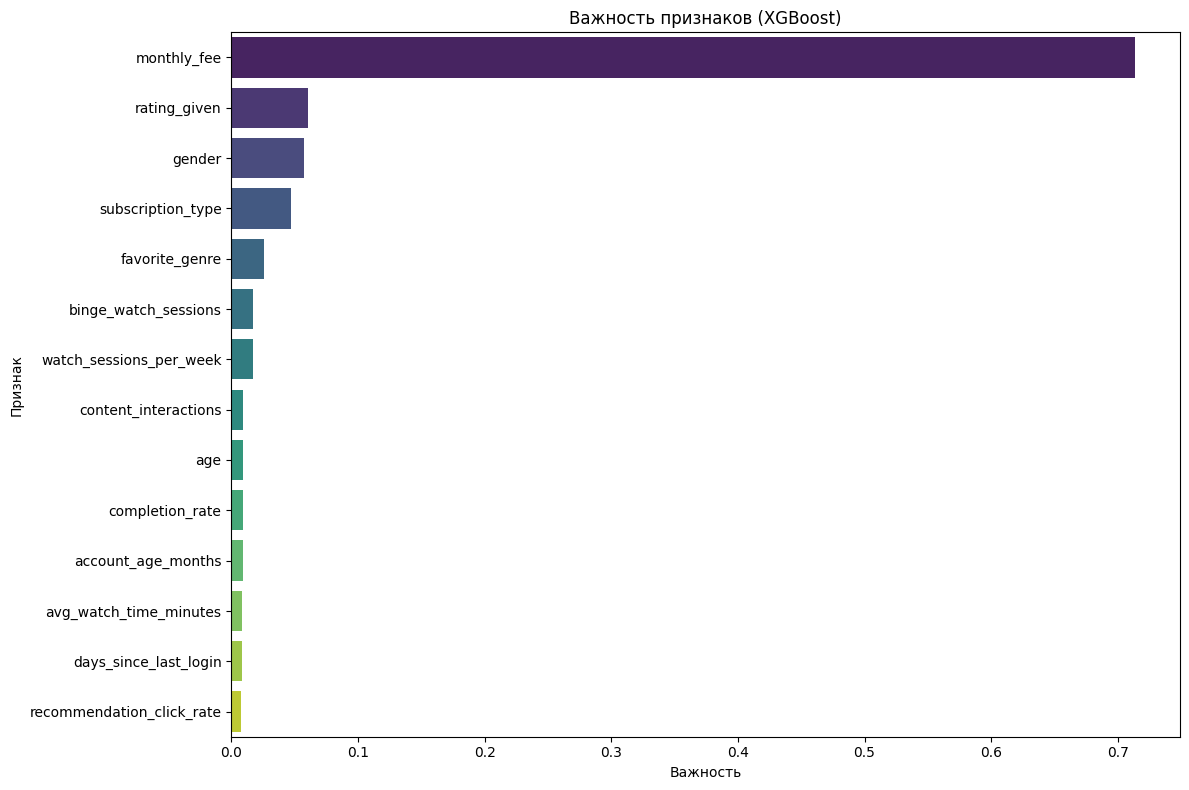

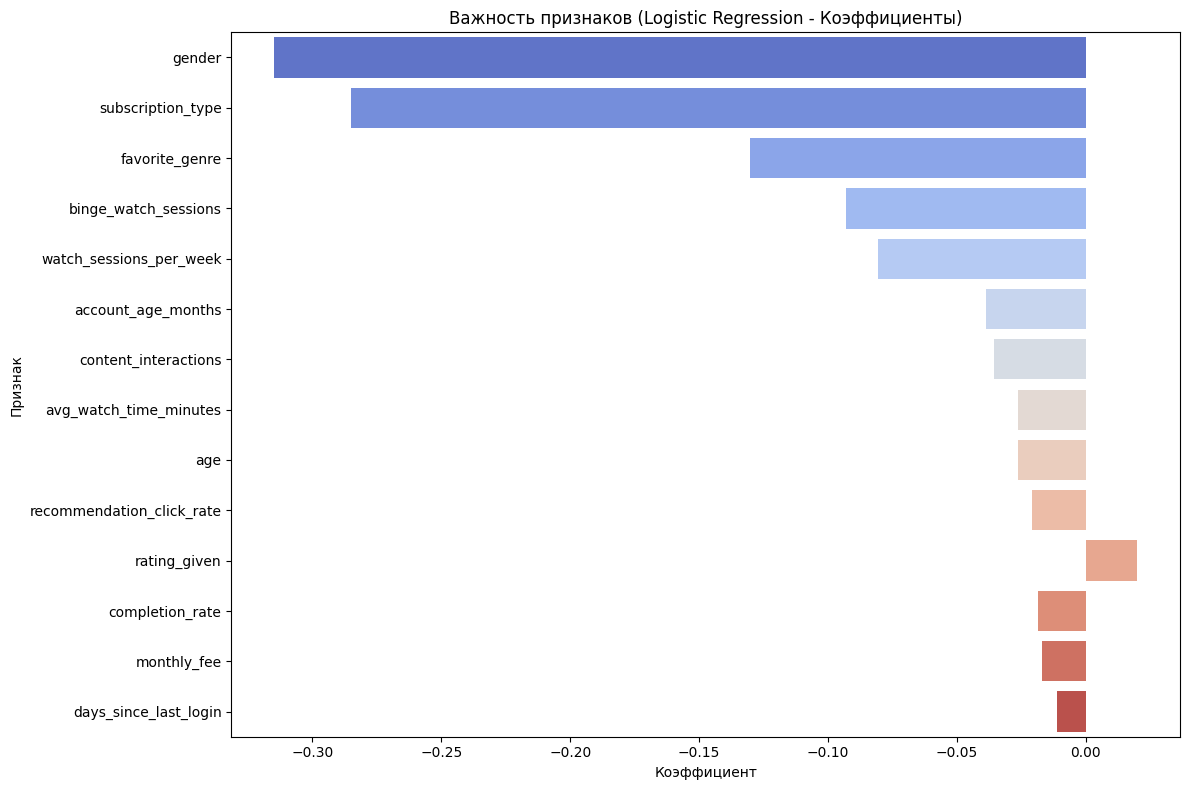

In [13]:
# 2. График важности признаков для Random Forest модели
# Assuming rf_pipeline and X are available from the classification training cell (rZX7Jm0MCczC)

# Extract feature importances from the trained Random Forest classifier
# The classifier is inside the pipeline, after the preprocessor.
feature_importances = rf_pipeline.named_steps['classifier'].feature_importances_

# Get feature names after preprocessing
# For numerical features, it's straightforward. Since we only used StandardScaler
# and X was defined before preprocessing in the classification cell, X.columns is correct.
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Важность признаков (Random Forest)')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

# 3. График важности признаков для XGBoost модели
# Assuming xgb_pipeline and X are available from the classification training cell (rZX7Jm0MCczC)

# Extract feature importances from the trained XGBoost classifier
# The classifier is inside the pipeline, after the preprocessor.
xgb_feature_importances = xgb_pipeline.named_steps['classifier'].feature_importances_

# Use the same feature names as X
xgb_feature_names = X.columns

# Create a DataFrame for better visualization
xgb_importance_df = pd.DataFrame({'Feature': xgb_feature_names, 'Importance': xgb_feature_importances})
xgb_importance_df = xgb_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=xgb_importance_df, palette='viridis')
plt.title('Важность признаков (XGBoost)')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

# 4. График важности признаков (коэффициенты) для Logistic Regression модели
# Assuming lr_pipeline and X are available from the classification training cell (rZX7Jm0MCczC)

# Extract coefficients from the trained Logistic Regression classifier
# The classifier is inside the pipeline.
# The coefficients represent feature importance for linear models.
lr_coefficients = lr_pipeline.named_steps['classifier'].coef_[0]

# Get feature names. These are the columns of X after preprocessing (scaling in this case)
# We need to get the feature names from the preprocessor step if there were transformations.
# Since we only scaled numerical columns and kept the order, X.columns is still valid.
lr_feature_names = X.columns

# Create a DataFrame for better visualization
lr_importance_df = pd.DataFrame({'Feature': lr_feature_names, 'Importance': lr_coefficients})
lr_importance_df['Abs_Importance'] = np.abs(lr_importance_df['Importance']) # Use absolute value for sorting
lr_importance_df = lr_importance_df.sort_values(by='Abs_Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=lr_importance_df, palette='coolwarm')
plt.title('Важность признаков (Logistic Regression - Коэффициенты)')
plt.xlabel('Коэффициент')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()


ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ
              Model  Accuracy
            XGBoost    0.7823
      Random Forest    0.7628
     Neural Network    0.7285
          SVM (RBF)    0.6052
Logistic Regression    0.5526


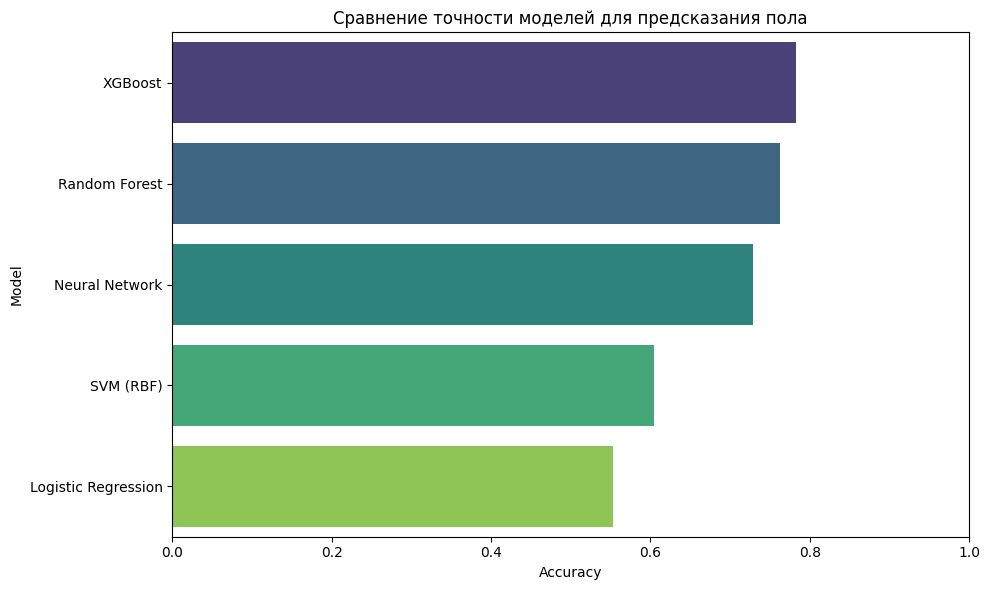

In [15]:
# Сравнение всех моделей
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
print("\n" + "="*50)
print("ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*50)
print(results_df.to_string(index=False))

# Визуализация (если нужно)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Accuracy', y='Model', palette='viridis')
plt.title('Сравнение точности моделей для предсказания пола')
plt.xlim(0, 1)
plt.xlabel('Accuracy')
plt.tight_layout()
plt.show()

Размер выборки: (5000, 20)
Числовые признаки: ['age', 'account_age_months', 'monthly_fee', 'devices_used', 'avg_watch_time_minutes', 'watch_sessions_per_week', 'binge_watch_sessions', 'completion_rate', 'rating_given', 'content_interactions', 'recommendation_click_rate', 'days_since_last_login']

K-Means:
  Кластеров: 3
  Silhouette: 0.062
  NMI с полом: 0.000

Agglomerative:
  Кластеров: 3
  Silhouette: 0.025
  NMI с полом: 0.000

GMM:
  Кластеров: 3
  Silhouette: 0.053
  NMI с полом: 0.000

Birch:
  Кластеров: 3
  Silhouette: 0.027
  NMI с полом: 0.000

Лучший алгоритм: K-Means


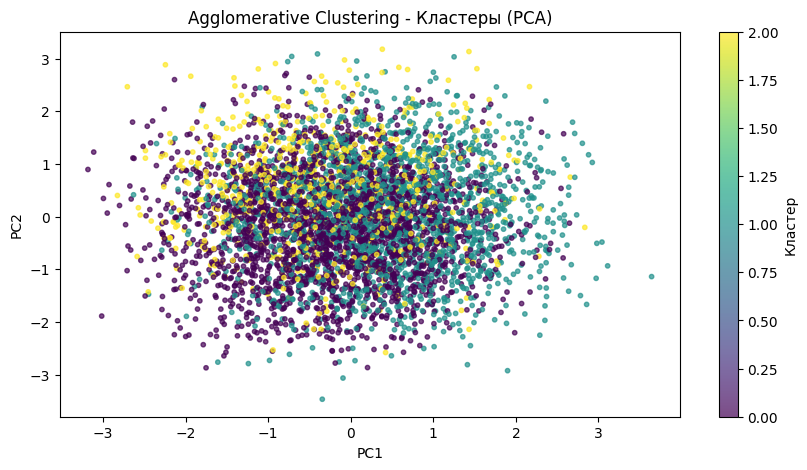

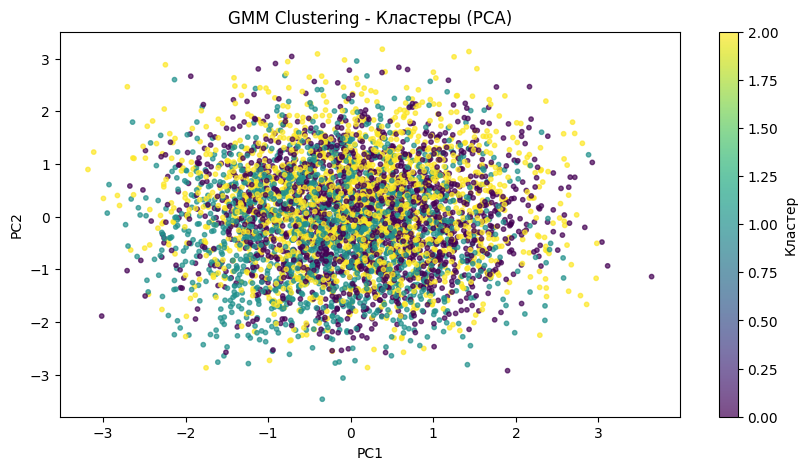

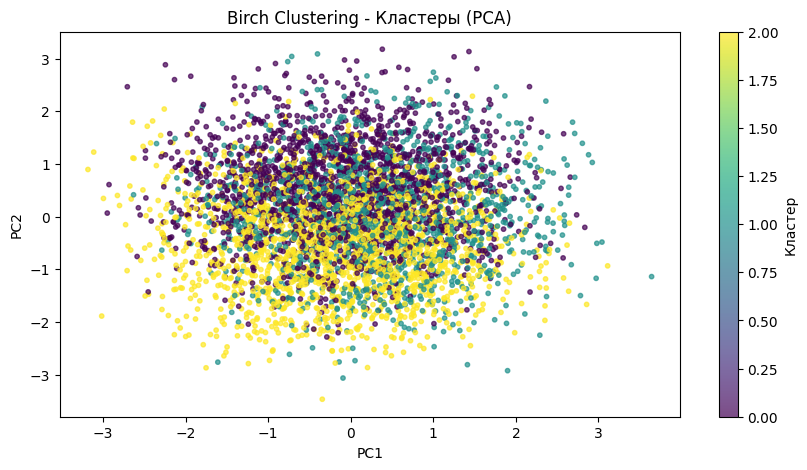

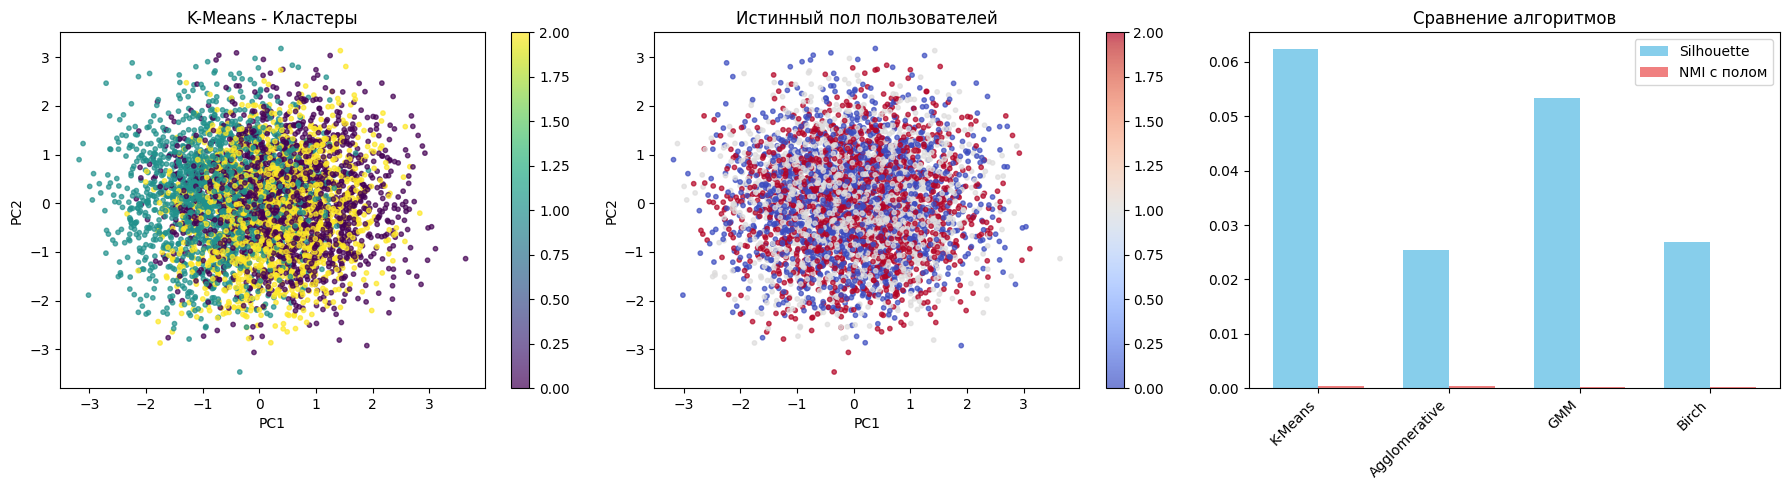


ХАРАКТЕРИСТИКИ КЛАСТЕРОВ

Средние значения признаков по кластерам:
           age  avg_watch_time_minutes  monthly_fee  devices_used
cluster                                                          
0        40.29                  155.23         7.99          2.00
1        40.78                  159.36        14.48          1.99
2        40.72                  149.40        14.44          1.97

Распределение пола по кластерам (%):
gender   Female  Male  Other
cluster                     
0          32.5  35.5   32.0
1          33.8  34.2   31.9
2          31.7  33.8   34.5


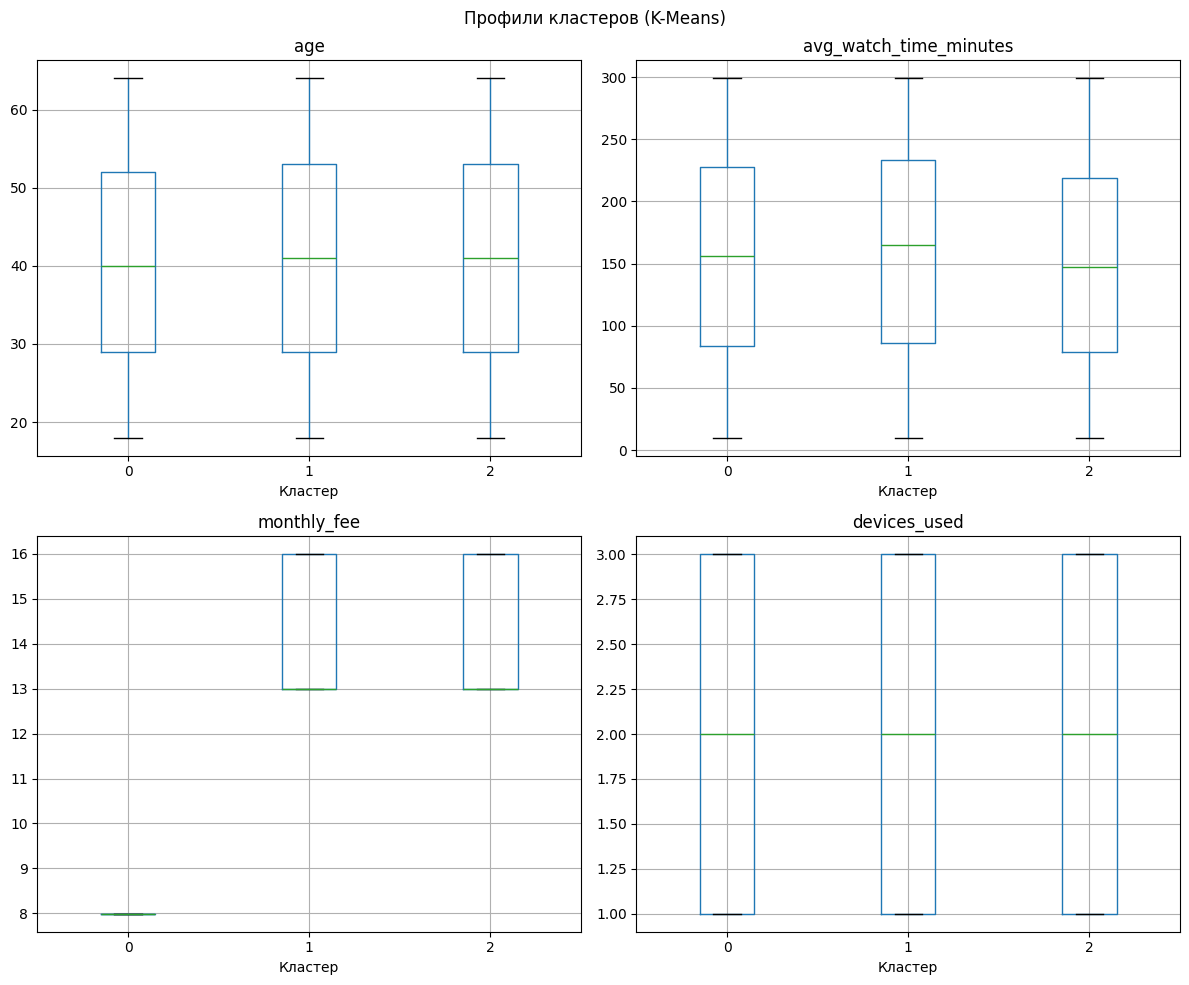


 Кластеризация выполнена успешно на 5000 пользователях.


In [3]:
# КЛАСТЕРИЗАЦИЯ

# Устанавливаем необходимые библиотеки (если нужно)
!pip install -q scikit-learn pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. ЗАГРУЗКА ДАННЫХ (БЕРЁМ ТОЛЬКО 5000 СТРОК) бо ОЗУ не бесконечная=)))
# ============================================

# Загружаем датасет (укажите правильный путь)
df = pd.read_csv('netflix.csv')
df = df.sample(n=5000, random_state=42)  # БЕРЁМ ТОЛЬКО 5000 СТРОК!
print(f"Размер выборки: {df.shape}")

# ============================================
# 2. МИНИМАЛЬНАЯ ПРЕДОБРАБОТКА
# ============================================

# Берём только числовые признаки
numerical_cols = ['age', 'account_age_months', 'monthly_fee', 'devices_used',
                  'avg_watch_time_minutes', 'watch_sessions_per_week',
                  'binge_watch_sessions', 'completion_rate', 'rating_given',
                  'content_interactions', 'recommendation_click_rate',
                  'days_since_last_login']

# Оставляем только существующие колонки
numerical_cols = [col for col in numerical_cols if col in df.columns]
print(f"Числовые признаки: {numerical_cols}")

# Масштабируем признаки
scaler = StandardScaler()
X = scaler.fit_transform(df[numerical_cols])

# Сохраняем пол для пост-анализа
y_true = df['gender'] if 'gender' in df.columns else None
if y_true is not None:
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_true)

# ============================================
# 3. АЛГОРИТМЫ КЛАСТЕРИЗАЦИИ
# ============================================

results = []

def simple_evaluation(labels, name, X, y_true=None):
    """Простая оценка кластеризации"""
    n_clusters = len(np.unique(labels))

    # Silhouette score
    if n_clusters > 1 and n_clusters < len(X):
        sil = silhouette_score(X, labels)
    else:
        sil = 0

    # Связь с полом (если есть)
    if y_true is not None and len(np.unique(labels)) > 1:
        from sklearn.metrics import normalized_mutual_info_score
        nmi = normalized_mutual_info_score(y_true, labels)
    else:
        nmi = 0

    print(f"\n{name}:")
    print(f"  Кластеров: {n_clusters}")
    print(f"  Silhouette: {sil:.3f}")
    print(f"  NMI с полом: {nmi:.3f}")

    return {'name': name, 'n_clusters': n_clusters, 'silhouette': sil, 'nmi': nmi}

# 3.1 K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X)
results.append(simple_evaluation(labels_kmeans, "K-Means", X, y_encoded if y_true is not None else None))

# 3.2 Agglomerative (иерархическая)
agglo = AgglomerativeClustering(n_clusters=3)
labels_agglo = agglo.fit_predict(X)
results.append(simple_evaluation(labels_agglo, "Agglomerative", X, y_encoded if y_true is not None else None))

# 3.3 Gaussian Mixture
gmm = GaussianMixture(n_components=3, random_state=42)
labels_gmm = gmm.fit_predict(X)
results.append(simple_evaluation(labels_gmm, "GMM", X, y_encoded if y_true is not None else None))

# 3.4 BIRCH (лёгкий алгоритм)
birch = Birch(n_clusters=3)
labels_birch = birch.fit_predict(X)
results.append(simple_evaluation(labels_birch, "Birch", X, y_encoded if y_true is not None else None))

# ============================================
# 4. ВИЗУАЛИЗАЦИЯ С PCA
# ============================================

# Уменьшаем размерность для графика
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Выбираем лучший алгоритм (по silhouette)
best_result = max(results, key=lambda x: x['silhouette'])
print(f"\nЛучший алгоритм: {best_result['name']}")

# --- Дополнительные графики для Agglomerative, GMM, Birch ---

# Agglomerative Clustering
plt.figure(figsize=(10, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_agglo, cmap='viridis', s=10, alpha=0.7)
plt.title('Agglomerative Clustering - Кластеры (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Кластер')
plt.show()

# GMM Clustering
plt.figure(figsize=(10, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_gmm, cmap='viridis', s=10, alpha=0.7)
plt.title('GMM Clustering - Кластеры (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Кластер')
plt.show()

# Birch Clustering
plt.figure(figsize=(10, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_birch, cmap='viridis', s=10, alpha=0.7)
plt.title('Birch Clustering - Кластеры (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Кластер')
plt.show()

# --- Оригинальный график для лучшего алгоритма ---

# Получаем метки лучшего алгоритма
if best_result['name'] == "K-Means":
    best_labels = labels_kmeans
elif best_result['name'] == "Agglomerative":
    best_labels = labels_agglo
elif best_result['name'] == "GMM":
    best_labels = labels_gmm
else:
    best_labels = labels_birch

# Рисуем график
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Кластеры
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap='viridis', s=10, alpha=0.7)
axes[0].set_title(f'{best_result["name"]} - Кластеры')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

# 2. Истинный пол (если есть)
if y_true is not None:
    scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap='coolwarm', s=10, alpha=0.7)
    axes[1].set_title('Истинный пол пользователей')
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC2')
    plt.colorbar(scatter2, ax=axes[1])
else:
    axes[1].text(0.5, 0.5, 'Нет данных о поле', ha='center', va='center')
    axes[1].set_title('Пол не указан')

# 3. Сравнение алгоритмов
alg_names = [r['name'] for r in results]
alg_sil = [r['silhouette'] for r in results]
alg_nmi = [r['nmi'] for r in results]

x = range(len(alg_names))
width = 0.35
axes[2].bar([i - width/2 for i in x], alg_sil, width, label='Silhouette', color='skyblue')
axes[2].bar([i + width/2 for i in x], alg_nmi, width, label='NMI с полом', color='lightcoral')
axes[2].set_xticks(x)
axes[2].set_xticklabels(alg_names, rotation=45, ha='right')
axes[2].set_title('Сравнение алгоритмов')
axes[2].legend()

plt.tight_layout()
plt.show()

# ============================================
# 5. АНАЛИЗ КЛАСТЕРОВ
# ============================================

# Добавляем кластеры в DataFrame
df_sample = df.iloc[:len(X)].copy()
df_sample['cluster'] = best_labels

print("\n" + "="*50)
print("ХАРАКТЕРИСТИКИ КЛАСТЕРОВ")
print("="*50)

# Средние значения по кластерам (основные признаки)
main_features = ['age', 'avg_watch_time_minutes', 'monthly_fee', 'devices_used']
main_features = [f for f in main_features if f in df_sample.columns]

cluster_profile = df_sample.groupby('cluster')[main_features].mean()
print("\nСредние значения признаков по кластерам:")
print(cluster_profile.round(2))

# Распределение пола по кластерам (если есть)
if 'gender' in df_sample.columns:
    print("\nРаспределение пола по кластерам (%):")
    gender_by_cluster = pd.crosstab(df_sample['cluster'], df_sample['gender'], normalize='index') * 100
    print(gender_by_cluster.round(1))

# Визуализация профилей
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(main_features[:4]):
    if feature in df_sample.columns:
        df_sample.boxplot(column=feature, by='cluster', ax=axes[i])
        axes[i].set_title(feature)
        axes[i].set_xlabel('Кластер')

plt.suptitle(f'Профили кластеров ({best_result["name"]})')
plt.tight_layout()
plt.show()

print("\n Кластеризация выполнена успешно на 5000 пользователях.")

Распределение пола по кластерам (%):


gender,Female,Male,Other
cluster,,,
0,32.537313,35.462687,32.000000
1,33.819065,34.244080,31.936855
2,31.704410,33.790226,34.505364


<Figure size 1000x600 with 0 Axes>

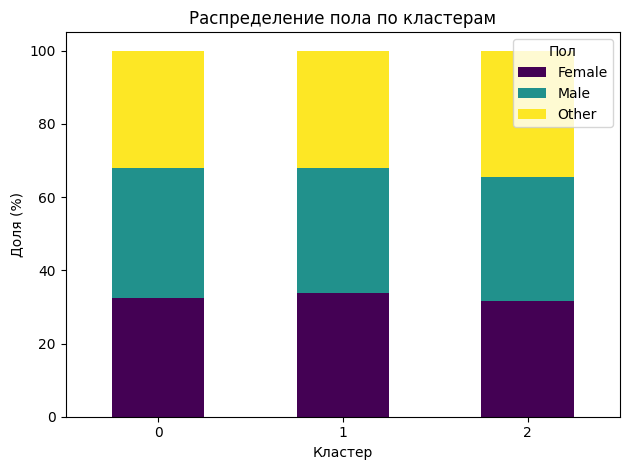

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming 'gender_by_cluster' is available from the clustering cell's execution
# Display the DataFrame
print("Распределение пола по кластерам (%):")
display(gender_by_cluster)

# Visualize the distribution
plt.figure(figsize=(10, 6))
gender_by_cluster.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Распределение пола по кластерам')
plt.xlabel('Кластер')
plt.ylabel('Доля (%)')
plt.xticks(rotation=0)
plt.legend(title='Пол', labels=['Female', 'Male', 'Other']) # Assuming these are the gender labels
plt.tight_layout()
plt.show()